# 투수 임베딩 v1 — Brier 최적화와 제출 artifact

이 노트북은 v0의 세부 실패 라벨, Main↔Trackman crosswalk, 이전 완료 시즌 Trackman 집계를 그대로 사용하면서 대회 평가·추론 규칙에 맞게 학습과 제출 단계를 보강합니다.

핵심 검증 순서는 다음과 같습니다.

1. `2019~2022 학습 → 2023 모델 선택·확률 보정 → 2024 최종 홀드아웃`
2. `control_success` 직접 예측 모델과 `reverse/middle/far residual` 조건부 모델 비교
3. 최종 성공확률의 Brier Score를 주 손실 및 모델 선택 기준으로 사용
4. 고정된 학습 통계·Trackman lookup·ID 사전만 제출 artifact에 포함
5. 평가 데이터의 다른 행이나 전체 분포를 전혀 사용하지 않는 행 독립 추론 코드와 결합

> **보조 라벨 주의**  
> reverse/middle 복원은 공식 `train.csv`만 이용하고 테스트 데이터는 사용하지 않습니다. 공개 규칙에 명시적 금지는 없지만, 누적률을 이용한 공개되지 않은 보조 정답 복원이 허용되는지는 운영진 확인 전까지 실험 기능으로 간주합니다. 그래서 직접 success head를 항상 함께 비교합니다.


In [1]:
from pathlib import Path
import gc
import json
import math
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 빠른 검증이 끝난 뒤 False로 바꾸면 전체 행을 사용합니다.
QUICK_RUN = True
MAX_TRAIN_ROWS = 350_000 if QUICK_RUN else None
MAX_VALID_ROWS = 100_000 if QUICK_RUN else None
EPOCHS = 3 if QUICK_RUN else 12
BATCH_SIZE = 4096

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "../../data/train.csv").resolve().exists():
    # 프로젝트 루트에서 직접 실행한 경우
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = (NOTEBOOK_DIR / "../..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "experiment" / "pitcher_embedding" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"project={PROJECT_ROOT}")
print(f"device={DEVICE}, torch={torch.__version__}, quick_run={QUICK_RUN}")


project=C:\Users\isj67\Desktop\LGAIMERS
device=cuda, torch=2.5.1+cu121, quick_run=True


## 1. 데이터 로드

Trackman은 ID 연결과 과거 구위 요약에 필요한 열만 읽습니다. 메인 데이터는 모델 후보 피처와 보조 라벨 복원 열을 읽습니다.

In [2]:
ASOF_COLS = [
    "asof_pitcher_n", "asof_pitcher_success_rate", "asof_pitcher_reverse_rate",
    "asof_pitcher_middle_rate", "asof_pitcher_ball_rate", "asof_pitcher_strike_rate",
    "asof_pitcher_prev1_game_success_rate", "asof_pitcher_prev3_game_success_rate",
    "asof_pitcher_prev5_game_success_rate", "asof_pitcher_prev1_game_middle_rate",
    "asof_pitcher_prev3_game_middle_rate", "asof_pitcher_prev5_game_middle_rate",
    "asof_batter_n", "asof_batter_success_rate", "asof_batter_middle_rate",
    "asof_pitcher_pitchmix_n", "asof_pitcher_fastball_rate",
    "asof_pitcher_breaking_rate", "asof_pitcher_offspeed_rate",
]

CONTEXT_COLS = [
    "row_id", "season", "game_month", "game_dayofweek", "inning", "top_bottom", "game_type",
    "balls_before", "strikes_before", "outs_before", "run_top_before", "run_bot_before",
    "run_total_before", "score_diff_home", "score_diff_pitcher_team",
    "runner_on_1b", "runner_on_2b", "runner_on_3b", "num_runners_on", "base_state",
    "home_win_expectancy", "away_win_expectancy", "li", "pitcher_id", "batter_id",
    "pitcher_hand", "batter_hand", "pitcher_team_id", "batter_team_id",
]

TM_FINGERPRINT_COLS = [
    "season", "pitcher_trackman_id", "pitcher_hand", "pitcher_team", "game_month",
    "game_dayofweek", "inning", "top_bottom", "balls_before", "strikes_before",
    "outs_before", "batter_hand",
]
TM_METRICS = [
    "rel_speed", "spin_rate", "induced_vert_break", "horz_break",
    "extension", "rel_height", "rel_side", "zone_speed",
]
TM_COLS = list(dict.fromkeys(TM_FINGERPRINT_COLS + ["pitch_type_group"] + TM_METRICS))

train = pd.read_csv(DATA_DIR / "train.csv", usecols=CONTEXT_COLS + ASOF_COLS + ["control_success"])
tm = pd.read_csv(DATA_DIR / "trackman_history.csv", usecols=TM_COLS)

print("train:", train.shape, "pitchers:", train.pitcher_id.nunique())
print("trackman:", tm.shape, "pitchers:", tm.pitcher_trackman_id.nunique())
display(train.head(3))


train: (1475092, 49) pitchers: 792
trackman: (1793078, 21) pitchers: 906


,row_id,season,game_month,game_dayofweek,inning,top_bottom,game_type,balls_before,strikes_before,outs_before,run_top_before,run_bot_before,run_total_before,score_diff_home,score_diff_pitcher_team,runner_on_1b,runner_on_2b,runner_on_3b,num_runners_on,base_state,home_win_expectancy,away_win_expectancy,li,pitcher_id,batter_id,pitcher_hand,batter_hand,pitcher_team_id,batter_team_id,asof_pitcher_n,asof_pitcher_success_rate,asof_pitcher_reverse_rate,asof_pitcher_middle_rate,asof_pitcher_ball_rate,asof_pitcher_strike_rate,asof_pitcher_prev1_game_success_rate,asof_pitcher_prev3_game_success_rate,asof_pitcher_prev5_game_success_rate,asof_pitcher_prev1_game_middle_rate,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
0,TRAIN_0000001,2019,3,5,1,T,R,0,0,0,0,0,0,0,0,0,0,0,0,___,50.0,50.0,0.87,21961,21996,1,2,16,13,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
1,TRAIN_0000002,2019,3,5,1,T,R,0,0,0,0,0,0,0,0,1,0,0,1,1__,46.5,53.5,1.44,21961,22103,1,1,16,13,1,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,1,1.0,0.0,0.0,0
2,TRAIN_0000003,2019,3,5,1,T,R,1,0,0,0,0,0,0,0,1,0,0,1,1__,46.5,53.5,1.44,21961,22103,1,1,16,13,2,0.0,0.5,0.0,0.5,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,0.0,2,1.0,0.0,0.0,0


## 2. 세부 실패 라벨 복원

같은 투수의 다음 투구 직전 누적값은 현재 투구까지 반영한 누적값입니다. 따라서

`현재 사건 = (다음 누적 건수 × 다음 누적률) - (현재 누적 건수 × 현재 누적률)`

로 현재 투구의 사건 여부를 복원할 수 있습니다. 마지막 투구처럼 다음 누적값이 없는 행은 학습에서 제외합니다.

In [3]:
def recover_binary_increment(df, rate_col):
    # 같은 투수의 다음 as-of 누적값을 이용해 현재 행의 0/1 사건을 복원한다.
    n = df["asof_pitcher_n"].astype(float)
    cumulative = n * df[rate_col].fillna(0.0).astype(float)
    next_n = df.groupby("pitcher_id", sort=False)["asof_pitcher_n"].shift(-1)
    next_cumulative = cumulative.groupby(df["pitcher_id"], sort=False).shift(-1)
    delta = next_cumulative - cumulative
    rounded = np.rint(delta)
    # 저장된 누적률은 소수점 반올림값이라 원래 0/1 사건에서 약 0.015까지 흔들린다.
    # 정수 반올림 결과가 0/1이고 반올림 오차가 0.05 미만일 때만 사용한다.
    valid = next_n.eq(n + 1) & rounded.isin([0, 1]) & (delta - rounded).abs().lt(0.05)
    recovered = pd.Series(np.nan, index=df.index, dtype="float32")
    recovered.loc[valid] = rounded.loc[valid].astype("float32")
    return recovered, valid


train["y_success_recovered"], valid_success = recover_binary_increment(train, "asof_pitcher_success_rate")
train["y_reverse"], valid_reverse = recover_binary_increment(train, "asof_pitcher_reverse_rate")
train["y_middle"], valid_middle = recover_binary_increment(train, "asof_pitcher_middle_rate")
train["y_ball_result"], valid_ball = recover_binary_increment(train, "asof_pitcher_ball_rate")

train["component_label_valid"] = valid_success & valid_reverse & valid_middle
train["y_far_residual"] = (
    train["control_success"].eq(0)
    & train["y_reverse"].eq(0)
    & train["y_middle"].eq(0)
).astype("float32")

valid = train["component_label_valid"]
reconstruction_accuracy = (
    train.loc[valid, "y_success_recovered"].astype(int)
    == train.loc[valid, "control_success"].astype(int)
).mean()

failure = train.loc[valid & train.control_success.eq(0)].copy()
failure["case"] = np.select(
    [
        failure.y_reverse.eq(1) & failure.y_middle.eq(0),
        failure.y_reverse.eq(0) & failure.y_middle.eq(1),
        failure.y_reverse.eq(1) & failure.y_middle.eq(1),
    ],
    ["reverse only", "middle only", "reverse & middle"],
    default="far residual",
)

label_report = pd.DataFrame({
    "value": [
        int(valid.sum()),
        reconstruction_accuracy,
        train.loc[valid, "y_reverse"].mean(),
        train.loc[valid, "y_middle"].mean(),
        train.loc[valid, "y_far_residual"].mean(),
        int((valid & train.control_success.eq(1) & train.y_reverse.eq(1)).sum()),
        int((valid & train.control_success.eq(1) & train.y_middle.eq(1)).sum()),
    ]
}, index=[
    "valid rows", "success reconstruction accuracy", "reverse rate", "middle rate",
    "far residual rate", "success & reverse contradictions", "success & middle contradictions",
])

display(label_report)
display((failure["case"].value_counts().to_frame("n").assign(rate=lambda x: x.n / x.n.sum())).sort_index())


,value
valid rows,1.474300e+06
success reconstruction accuracy,1.000000e+00
reverse rate,2.290355e-01
middle rate,1.496052e-01
far residual rate,1.317208e-01
success & reverse contradictions,0.000000e+00
success & middle contradictions,0.000000e+00


,n,rate
case,,
far residual,194196,0.276569
middle only,170297,0.242533
reverse & middle,50266,0.071588
reverse only,287401,0.409310


## 3. Main ↔ Trackman 투수 ID crosswalk

직접 공통 ID가 없으므로 같은 시즌의 투구 상황 분포를 투수별 지문으로 사용합니다.

- 월, 요일, 이닝, 초/말, 볼·스트라이크·아웃, 상대 타자 손잡이의 결합 빈도
- 같은 시즌·같은 투수 손잡이 후보끼리 cosine similarity 비교
- 최고 유사도 `≥ 0.80`, 2위와의 차이 `≥ 0.02`만 고신뢰 매칭으로 채택
- 여러 시즌에서 고신뢰 매칭된 경우 동일 Trackman ID인지 검사
- 하나의 Trackman ID에 복수 Main ID가 걸리면 평균 신뢰도가 높은 하나만 남김

이 연결은 타깃을 전혀 사용하지 않습니다.

In [4]:
def make_state_code(df, is_main):
    month = df["game_month"].to_numpy(np.int64)
    dow = df["game_dayofweek"].to_numpy(np.int64)
    inning = np.minimum(df["inning"].to_numpy(np.int64), 20)
    if is_main:
        bottom = df["top_bottom"].astype(str).eq("B").to_numpy(np.int64)
        batter_right = df["batter_hand"].to_numpy(np.int64) == 2
    else:
        bottom = df["top_bottom"].astype(str).eq("Bottom").to_numpy(np.int64)
        batter_right = df["batter_hand"].astype(str).eq("Right").to_numpy(np.int64)

    code = month.copy()
    for values, base in [
        (dow, 7), (inning, 21), (bottom, 2),
        (df["balls_before"].to_numpy(np.int64), 4),
        (df["strikes_before"].to_numpy(np.int64), 3),
        (df["outs_before"].to_numpy(np.int64), 3),
        (batter_right, 2),
    ]:
        code = code * base + values
    return code


def build_pitcher_season_matches(main_df, tm_df):
    main_fp = main_df[[
        "season", "pitcher_id", "pitcher_hand", "game_month", "game_dayofweek", "inning",
        "top_bottom", "balls_before", "strikes_before", "outs_before", "batter_hand",
    ]].copy()
    tm_fp = tm_df[TM_FINGERPRINT_COLS].copy()
    main_fp["state"] = make_state_code(main_fp, is_main=True)
    tm_fp["state"] = make_state_code(tm_fp, is_main=False)

    records = []
    for season in sorted(main_fp.season.unique()):
        a = main_fp[main_fp.season.eq(season)]
        b = tm_fp[tm_fp.season.eq(season)]
        main_ids = np.sort(a.pitcher_id.unique())
        tm_ids = np.sort(b.pitcher_trackman_id.unique())
        main_index = {v: i for i, v in enumerate(main_ids)}
        tm_index = {v: i for i, v in enumerate(tm_ids)}
        states = np.union1d(a.state.unique(), b.state.unique())
        state_index = {v: i for i, v in enumerate(states)}

        ag = a.groupby(["pitcher_id", "state"], sort=False).size().reset_index(name="n")
        bg = b.groupby(["pitcher_trackman_id", "state"], sort=False).size().reset_index(name="n")
        A = sparse.csr_matrix(
            (ag.n, (ag.pitcher_id.map(main_index), ag.state.map(state_index))),
            shape=(len(main_ids), len(states)), dtype=np.float32,
        )
        B = sparse.csr_matrix(
            (bg.n, (bg.pitcher_trackman_id.map(tm_index), bg.state.map(state_index))),
            shape=(len(tm_ids), len(states)), dtype=np.float32,
        )
        A = sparse.diags(1 / np.sqrt(A.multiply(A).sum(1).A1).clip(1e-9)) @ A
        B = sparse.diags(1 / np.sqrt(B.multiply(B).sum(1).A1).clip(1e-9)) @ B
        similarity = (A @ B.T).toarray()

        main_hand = a.groupby("pitcher_id").pitcher_hand.first().reindex(main_ids).to_numpy()
        tm_hand_raw = b.groupby("pitcher_trackman_id").pitcher_hand.first().reindex(tm_ids).to_numpy()
        tm_hand = np.where(tm_hand_raw == "Left", 1, 2)
        similarity[main_hand[:, None] != tm_hand[None, :]] = -1

        order = np.argsort(similarity, axis=1)
        best, second = order[:, -1], order[:, -2]
        main_n = a.groupby("pitcher_id").size().reindex(main_ids).to_numpy()
        tm_n = b.groupby("pitcher_trackman_id").size().reindex(tm_ids).to_numpy()

        for i, pitcher_id in enumerate(main_ids):
            records.append({
                "season": season,
                "pitcher_id": pitcher_id,
                "pitcher_trackman_id": tm_ids[best[i]],
                "similarity": float(np.clip(similarity[i, best[i]], -1, 1)),
                "second_similarity": float(np.clip(similarity[i, second[i]], -1, 1)),
                "margin": float(similarity[i, best[i]] - similarity[i, second[i]]),
                "main_n": int(main_n[i]),
                "trackman_n": int(tm_n[best[i]]),
            })
    return pd.DataFrame(records)


pitcher_season_matches = build_pitcher_season_matches(train, tm)
high_conf = pitcher_season_matches.query("similarity >= 0.80 and margin >= 0.02").copy()

vote_table = (
    high_conf.groupby(["pitcher_id", "pitcher_trackman_id"], as_index=False)
    .agg(cw_match_seasons=("season", "nunique"), cw_mean_sim=("similarity", "mean"),
         cw_min_margin=("margin", "min"), cw_total_main_n=("main_n", "sum"))
    .sort_values(["pitcher_id", "cw_match_seasons", "cw_mean_sim", "cw_total_main_n"], ascending=[True, False, False, False])
)
crosswalk = vote_table.drop_duplicates("pitcher_id", keep="first").copy()

# 한 Trackman ID를 여러 Main ID에 붙이지 않는다.
crosswalk = (
    crosswalk.sort_values(["pitcher_trackman_id", "cw_match_seasons", "cw_mean_sim", "cw_total_main_n"],
                          ascending=[True, False, False, False])
    .drop_duplicates("pitcher_trackman_id", keep="first")
    .sort_values("pitcher_id")
    .reset_index(drop=True)
)

check = high_conf.merge(crosswalk[["pitcher_id", "pitcher_trackman_id"]], on="pitcher_id", suffixes=("", "_selected"))
season_agreement = (check.pitcher_trackman_id == check.pitcher_trackman_id_selected).mean()
row_coverage = train.pitcher_id.isin(crosswalk.pitcher_id).mean()

crosswalk.to_parquet(OUTPUT_DIR / "main_trackman_pitcher_crosswalk.parquet", index=False)
pitcher_season_matches.to_parquet(OUTPUT_DIR / "pitcher_season_match_diagnostics.parquet", index=False)

crosswalk_report = pd.DataFrame({
    "value": [len(pitcher_season_matches), len(high_conf), len(crosswalk), season_agreement, row_coverage]
}, index=["all pitcher-seasons", "high-confidence pitcher-seasons", "accepted pitchers", "multi-season agreement", "main row coverage"])
display(crosswalk_report)
display(pitcher_season_matches[["similarity", "margin"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]))
display(crosswalk.head())


,value
all pitcher-seasons,2260.000000
high-confidence pitcher-seasons,1019.000000
accepted pitchers,419.000000
multi-season agreement,1.000000
main row coverage,0.862979


,similarity,margin
count,2260.000000,2260.000000
mean,0.682311,0.580588
std,0.265606,0.268299
min,0.004991,0.000026
10%,0.286582,0.163440
25%,0.469816,0.366351
50%,0.751401,0.658948
75%,0.926175,0.820061
90%,0.964597,0.861767
95%,0.981711,0.882933


,pitcher_id,pitcher_trackman_id,cw_match_seasons,cw_mean_sim,cw_min_margin,cw_total_main_n
0,20700,99445,2,0.925940,0.854215,959
1,20938,70425,1,0.888533,0.810863,638
2,21170,71837,1,1.000000,0.904556,20
3,21279,72447,2,0.872431,0.802840,802
4,21372,72523,4,0.936453,0.841218,3602


## 4. 이전 완료 시즌 Trackman 피처와 신인 cohort

예측 시즌 `s`의 입력에는 `season < s`인 Trackman 행만 사용합니다. 구속·회전·무브먼트의 평균/표준편차, 구종군 비율, 이전 시즌 및 누적 투구 수를 만듭니다.

신인/저표본 cohort는 다음처럼 모델 입력 시점에 알 수 있는 값만 사용합니다.

- `UNSEEN`: 현재까지 메인 이력도 없고 과거 Trackman도 없음
- `ROOKIE_1_25`: 과거 어떤 완료 시즌도 100구를 넘지 않았고 현재 누적 1~25구
- `ROOKIE_26_100`: 같은 조건에서 현재 누적 26~100구
- `RETURNING`: 과거 100구 초과 시즌은 있으나 직전 시즌 Trackman 기록 없음
- `VETERAN`: 그 외

`same_season_low_volume`은 요청하신 “그 시즌 100구 이하” 분석 태그지만 시즌 종료 후에만 확정되므로 모델 입력에서 제외합니다.

In [5]:
def build_lagged_trackman(tm_df, cutoffs=range(2019, 2026)):
    frames = []
    season_counts = (
        tm_df.groupby(["pitcher_trackman_id", "season"]).size()
        .rename("season_n").reset_index()
    )

    for cutoff in cutoffs:
        prior = tm_df[tm_df.season.lt(cutoff)]
        if prior.empty:
            continue
        grouped = prior.groupby("pitcher_trackman_id", sort=False)
        stats = grouped[TM_METRICS].agg(["mean", "std"])
        stats.columns = [f"tm_{metric}_{stat}" for metric, stat in stats.columns]
        stats = stats.reset_index()
        stats["tm_prior_n"] = grouped.size().reindex(stats.pitcher_trackman_id).to_numpy()

        mix = pd.crosstab(prior.pitcher_trackman_id, prior.pitch_type_group, normalize="index")
        for group_name in ["fastball", "breaking", "offspeed", "other"]:
            if group_name not in mix.columns:
                mix[group_name] = 0.0
        mix = mix[["fastball", "breaking", "offspeed", "other"]]
        mix.columns = [f"tm_pitch_group_{c}_rate" for c in mix.columns]
        mix = mix.reset_index()

        prior_counts = season_counts[season_counts.season.lt(cutoff)]
        max_n = prior_counts.groupby("pitcher_trackman_id").season_n.max().rename("tm_prior_max_season_n")
        prev_n = (
            season_counts[season_counts.season.eq(cutoff - 1)]
            .set_index("pitcher_trackman_id").season_n.rename("tm_prev_season_n")
        )

        out = stats.merge(mix, on="pitcher_trackman_id", how="left")
        out = out.join(max_n, on="pitcher_trackman_id").join(prev_n, on="pitcher_trackman_id")
        out["season"] = cutoff
        frames.append(out)
    return pd.concat(frames, ignore_index=True)


lagged_tm = build_lagged_trackman(tm)
model_df = train.merge(crosswalk, on="pitcher_id", how="left")
model_df = model_df.merge(lagged_tm, on=["pitcher_trackman_id", "season"], how="left")

for col in ["tm_prior_n", "tm_prev_season_n", "tm_prior_max_season_n"]:
    model_df[col] = model_df[col].fillna(0)
model_df["tm_available"] = model_df.tm_prior_n.gt(0).astype("float32")

established = model_df.tm_prior_max_season_n.gt(100)
current_n = model_df.asof_pitcher_n
model_df["experience_cohort"] = np.select(
    [
        current_n.eq(0) & model_df.tm_prior_n.eq(0),
        ~established & current_n.le(25),
        ~established & current_n.le(100),
        established & model_df.tm_prev_season_n.eq(0),
    ],
    ["UNSEEN", "ROOKIE_1_25", "ROOKIE_26_100", "RETURNING"],
    default="VETERAN",
)

season_volume = model_df.groupby(["season", "pitcher_id"]).size().rename("same_season_pitch_n")
model_df = model_df.join(season_volume, on=["season", "pitcher_id"])
model_df["same_season_low_volume"] = model_df.same_season_pitch_n.le(100)

feature_coverage = (
    model_df.groupby("season")
    .agg(rows=("row_id", "size"), crosswalk_rate=("pitcher_trackman_id", lambda s: s.notna().mean()),
         prior_trackman_rate=("tm_available", "mean"), low_volume_rate=("same_season_low_volume", "mean"))
)
display(feature_coverage)
display(pd.crosstab(model_df.season, model_df.experience_cohort, normalize="index").round(4))

del lagged_tm
gc.collect()


,rows,crosswalk_rate,prior_trackman_rate,low_volume_rate
season,,,,
2019,237413,0.870677,0.000000,0.019300
2020,244087,0.877847,0.696153,0.014310
2021,247088,0.862539,0.708885,0.018580
2022,247472,0.873545,0.752065,0.018851
2023,245525,0.867101,0.768089,0.019363
2024,253507,0.827575,0.690734,0.018043


experience_cohort,RETURNING,ROOKIE_1_25,ROOKIE_26_100,UNSEEN,VETERAN
season,,,,,
2019,0.0000,0.0364,0.0924,0.0015,0.8697
2020,0.0000,0.0111,0.0305,0.0004,0.9580
2021,0.0077,0.0093,0.0229,0.0004,0.9597
2022,0.0483,0.0084,0.0208,0.0003,0.9222
2023,0.0209,0.0064,0.0175,0.0003,0.9549
2024,0.0272,0.0077,0.0224,0.0003,0.9424


20

## 5. Brier 중심 시간 검증 설계

2024를 모델 선택에 사용하지 않기 위해 아래처럼 완전히 시간 순방향으로 분리합니다.

- 학습: 2019~2022
- 선택·보정: 2023
- 최종 홀드아웃: 2024

빠른 모드는 각 구간을 표본화합니다. `QUICK_RUN=False`로 바꾸면 전체 행을 사용합니다. 전처리 통계와 투수 ID 사전은 학습 구간에서만 적합합니다.

In [6]:
HISTORY_FEATURES = [
    "season", "game_month", "game_dayofweek", "inning", "balls_before", "strikes_before", "outs_before",
    "run_top_before", "run_bot_before", "run_total_before", "score_diff_home", "score_diff_pitcher_team",
    "runner_on_1b", "runner_on_2b", "runner_on_3b", "num_runners_on",
    "home_win_expectancy", "away_win_expectancy", "li", "pitcher_hand", "batter_hand",
] + ASOF_COLS

TRACKMAN_COUNT_RAW = ["tm_prior_n", "tm_prev_season_n", "tm_prior_max_season_n"]
TRACKMAN_BASE_FEATURES = [
    c for c in model_df.columns
    if c.startswith("tm_") and c != "tm_available"
] + ["tm_available"]

for source in ["asof_pitcher_n", "asof_batter_n", "asof_pitcher_pitchmix_n"]:
    new_col = f"log1p_{source}"
    model_df[new_col] = np.log1p(model_df[source].clip(lower=0))
    HISTORY_FEATURES.remove(source)
    HISTORY_FEATURES.append(new_col)

TRACKMAN_FEATURES = TRACKMAN_BASE_FEATURES.copy()
for source in TRACKMAN_COUNT_RAW:
    new_col = f"log1p_{source}"
    model_df[new_col] = np.log1p(model_df[source].clip(lower=0))
    TRACKMAN_FEATURES.remove(source)
    TRACKMAN_FEATURES.append(new_col)

def sample_indices(pool, limit, seed):
    pool = np.asarray(pool)
    if limit is None or len(pool) <= limit:
        return np.sort(pool)
    return np.sort(np.random.default_rng(seed).choice(pool, limit, replace=False))

eligible = model_df.component_label_valid
fit_pool = model_df.index[eligible & model_df.season.le(2022)]
select_pool = model_df.index[eligible & model_df.season.eq(2023)]
holdout_pool = model_df.index[eligible & model_df.season.eq(2024)]

fit_idx = sample_indices(fit_pool, 350_000 if QUICK_RUN else None, SEED)
select_idx = sample_indices(select_pool, 100_000 if QUICK_RUN else None, SEED + 1)
holdout_idx = sample_indices(holdout_pool, 100_000 if QUICK_RUN else None, SEED + 2)

def fit_preprocessor(frame, columns):
    x = frame[columns].to_numpy(dtype=np.float64)
    median = np.nanmedian(x, axis=0)
    median = np.where(np.isfinite(median), median, 0.0)
    x = np.where(np.isfinite(x), x, median)
    mean = x.mean(axis=0)
    scale = x.std(axis=0)
    scale = np.where(scale > 1e-8, scale, 1.0)
    return {"median": median.astype("float32"), "mean": mean.astype("float32"), "scale": scale.astype("float32")}

def transform_numeric(frame, columns, prep):
    x = frame[columns].to_numpy(dtype=np.float32)
    x = np.where(np.isfinite(x), x, prep["median"])
    return ((x - prep["mean"]) / prep["scale"]).astype("float32")

hist_prep = fit_preprocessor(model_df.loc[fit_idx], HISTORY_FEATURES)
tm_prep = fit_preprocessor(model_df.loc[fit_idx], TRACKMAN_FEATURES)

known_pitchers = np.sort(model_df.loc[model_df.season.le(2022), "pitcher_id"].unique())
pitcher_to_index = {int(pid): i + 1 for i, pid in enumerate(known_pitchers)}
COHORTS = ["UNSEEN", "ROOKIE_1_25", "ROOKIE_26_100", "RETURNING", "VETERAN"]
cohort_to_index = {name: i for i, name in enumerate(COHORTS)}

TARGET_COLS = ["y_reverse", "y_middle", "y_far_residual", "control_success"]

def encode_metadata(frame, pitcher_map):
    pitcher_idx = frame.pitcher_id.map(pitcher_map).fillna(0).astype("int64").to_numpy()
    cohort_idx = frame.experience_cohort.map(cohort_to_index).astype("int64").to_numpy()
    asof_n = frame.asof_pitcher_n.astype("float32").to_numpy()
    return pitcher_idx, cohort_idx, asof_n

def make_arrays(index, hist_preprocessor, tm_preprocessor, pitcher_map):
    frame = model_df.loc[index]
    h = transform_numeric(frame, HISTORY_FEATURES, hist_preprocessor)
    t = transform_numeric(frame, TRACKMAN_FEATURES, tm_preprocessor)
    p, c, n = encode_metadata(frame, pitcher_map)
    y = frame[TARGET_COLS].to_numpy("float32")
    return h, t, p, c, n, y

fit_arrays = make_arrays(fit_idx, hist_prep, tm_prep, pitcher_to_index)
select_arrays = make_arrays(select_idx, hist_prep, tm_prep, pitcher_to_index)
holdout_arrays = make_arrays(holdout_idx, hist_prep, tm_prep, pitcher_to_index)

def make_loader(arrays, shuffle, batch_size=BATCH_SIZE):
    tensors = [torch.from_numpy(x) for x in arrays]
    dataset = TensorDataset(*tensors)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0,
                      pin_memory=torch.cuda.is_available())

fit_loader = make_loader(fit_arrays, True)
select_loader = make_loader(select_arrays, False)
holdout_loader = make_loader(holdout_arrays, False)

print(f"fit={len(fit_idx):,}, select={len(select_idx):,}, holdout={len(holdout_idx):,}")
print(f"history={len(HISTORY_FEATURES)}, trackman={len(TRACKMAN_FEATURES)}, pitcher tokens={len(pitcher_to_index)}")


fit=350,000, select=100,000, holdout=100,000
history=40, trackman=24, pitcher tokens=648


## 6. 비교 모델

두 모델은 같은 backbone과 32차원 임베딩을 사용합니다.

- `direct`: `control_success`를 직접 예측하고 Brier Loss로 학습
- `component`: reverse/middle/far 조건부 확률을 학습하고 곱으로 성공확률 계산

두 모델 모두 최종 성공확률 Brier를 주 손실로 사용합니다. component 모델의 조건부 BCE는 표현 학습을 돕는 보조 손실입니다. LayerNorm을 사용해 추론 배치의 다른 행에 영향을 받지 않도록 했습니다.

In [7]:
class PitcherBrierNet(nn.Module):
    def __init__(self, hist_dim, tm_dim, n_pitchers, n_cohorts, mode, embedding_dim=32):
        super().__init__()
        if mode not in {"direct", "component"}:
            raise ValueError(mode)
        self.mode = mode
        self.pitcher_embedding = nn.Embedding(n_pitchers + 1, 16, padding_idx=0)
        self.cohort_embedding = nn.Embedding(n_cohorts, 8)
        self.history_tower = nn.Sequential(
            nn.Linear(hist_dim, 96), nn.LayerNorm(96), nn.SiLU(), nn.Dropout(0.10),
            nn.Linear(96, 48), nn.SiLU(),
        )
        self.trackman_tower = nn.Sequential(
            nn.Linear(tm_dim, 64), nn.LayerNorm(64), nn.SiLU(), nn.Dropout(0.10),
            nn.Linear(64, 24), nn.SiLU(),
        )
        self.individual_projection = nn.Linear(16, 16)
        self.cohort_projection = nn.Linear(8, 16)
        self.fusion = nn.Sequential(
            nn.Linear(48 + 24 + 16 + 8, 64), nn.SiLU(), nn.Dropout(0.10),
            nn.Linear(64, embedding_dim), nn.LayerNorm(embedding_dim), nn.SiLU(),
        )
        self.direct_head = nn.Linear(embedding_dim, 1)
        self.reverse_head = nn.Linear(embedding_dim, 1)
        self.middle_head = nn.Linear(embedding_dim, 1)
        self.far_head = nn.Linear(embedding_dim, 1)

    def forward(self, history_x, trackman_x, pitcher_idx, cohort_idx, asof_n):
        history_h = self.history_tower(history_x)
        trackman_h = self.trackman_tower(trackman_x)
        individual = self.individual_projection(self.pitcher_embedding(pitcher_idx))
        cohort_raw = self.cohort_embedding(cohort_idx)
        cohort = self.cohort_projection(cohort_raw)
        alpha = (asof_n / (asof_n + 100.0)).clamp(0, 1).unsqueeze(1)
        alpha = alpha * pitcher_idx.ne(0).float().unsqueeze(1)
        pitcher_h = alpha * individual + (1 - alpha) * cohort
        embedding = self.fusion(torch.cat([history_h, trackman_h, pitcher_h, cohort_raw], dim=1))
        direct_logit = self.direct_head(embedding).squeeze(1)
        component_logits = torch.cat([
            self.reverse_head(embedding), self.middle_head(embedding), self.far_head(embedding)
        ], dim=1)
        return direct_logit, component_logits, embedding

    def success_probability(self, direct_logit, component_logits):
        if self.mode == "direct":
            return torch.sigmoid(direct_logit)
        component_p = torch.sigmoid(component_logits)
        return torch.prod(1 - component_p, dim=1)


binary_bce = nn.BCEWithLogitsLoss(reduction="none")

def model_loss(model, direct_logit, component_logits, y):
    success_p = model.success_probability(direct_logit, component_logits)
    brier = torch.mean((success_p - y[:, 3]) ** 2)
    if model.mode == "direct":
        success_bce = binary_bce(direct_logit, y[:, 3]).mean()
        return brier + 0.05 * success_bce, {"brier": brier.detach(), "aux": success_bce.detach()}

    reverse_loss = binary_bce(component_logits[:, 0], y[:, 0]).mean()
    no_reverse = y[:, 0].eq(0)
    middle_loss = binary_bce(component_logits[no_reverse, 1], y[no_reverse, 1]).mean()
    neither = no_reverse & y[:, 1].eq(0)
    far_loss = binary_bce(component_logits[neither, 2], y[neither, 2]).mean()
    auxiliary = reverse_loss + middle_loss + far_loss
    return brier + 0.10 * auxiliary, {"brier": brier.detach(), "aux": auxiliary.detach()}

@torch.no_grad()
def predict_model(model, loader, return_embeddings=False):
    model.eval()
    probabilities, targets, embeddings = [], [], []
    for history_x, trackman_x, pitcher_idx, cohort_idx, asof_n, y in loader:
        direct_logit, component_logits, embedding = model(
            history_x.to(DEVICE), trackman_x.to(DEVICE), pitcher_idx.to(DEVICE),
            cohort_idx.to(DEVICE), asof_n.to(DEVICE),
        )
        probabilities.append(model.success_probability(direct_logit, component_logits).cpu().numpy())
        targets.append(y[:, 3].numpy())
        if return_embeddings:
            embeddings.append(embedding.cpu().numpy())
    result = (np.concatenate(probabilities), np.concatenate(targets))
    if return_embeddings:
        result += (np.concatenate(embeddings),)
    return result

def brier_report(y, p):
    p = np.clip(np.asarray(p), 1e-7, 1 - 1e-7)
    y = np.asarray(y)
    brier = float(np.mean((p - y) ** 2))
    reference = float(y.mean() * (1 - y.mean()))
    skill = max(0.0, 100000.0 * (1 - brier / reference)) if reference > 0 else 0.0
    return {"brier": brier, "bss": skill, "logloss": log_loss(y, p, labels=[0, 1]),
            "auc": roc_auc_score(y, p), "pred_mean": float(p.mean()), "target_mean": float(y.mean())}

def train_candidate(mode, epochs=EPOCHS):
    torch.manual_seed(SEED + (0 if mode == "direct" else 100))
    model = PitcherBrierNet(len(HISTORY_FEATURES), len(TRACKMAN_FEATURES), len(pitcher_to_index),
                            len(COHORTS), mode=mode).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_state, best_brier = None, float("inf")
    rows = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = total_brier = seen = 0.0
        for history_x, trackman_x, pitcher_idx, cohort_idx, asof_n, y in fit_loader:
            history_x, trackman_x = history_x.to(DEVICE), trackman_x.to(DEVICE)
            pitcher_idx, cohort_idx, asof_n, y = pitcher_idx.to(DEVICE), cohort_idx.to(DEVICE), asof_n.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            direct_logit, component_logits, _ = model(history_x, trackman_x, pitcher_idx, cohort_idx, asof_n)
            loss, parts = model_loss(model, direct_logit, component_logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            n = len(y)
            total_loss += loss.item() * n
            total_brier += parts["brier"].item() * n
            seen += n
        select_p, select_y = predict_model(model, select_loader)
        report = brier_report(select_y, select_p)
        rows.append({"mode": mode, "epoch": epoch, "train_loss": total_loss / seen,
                     "train_brier": total_brier / seen, "select_brier": report["brier"], "select_bss": report["bss"]})
        if report["brier"] < best_brier:
            best_brier = report["brier"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"{mode:9s} epoch {epoch:02d} | train_brier={total_brier/seen:.6f} | "
              f"2023_brier={report['brier']:.6f} | BSS={report['bss']:.2f}")
    model.load_state_dict(best_state)
    return model, pd.DataFrame(rows)


candidates = {}
training_curves = []
for candidate_mode in ["direct", "component"]:
    candidate_model, curve = train_candidate(candidate_mode)
    candidates[candidate_mode] = candidate_model
    training_curves.append(curve)

display(pd.concat(training_curves, ignore_index=True))


direct    epoch 01 | train_brier=0.246602 | 2023_brier=0.249763 | BSS=93.73


direct    epoch 02 | train_brier=0.245186 | 2023_brier=0.250658 | BSS=0.00


direct    epoch 03 | train_brier=0.244931 | 2023_brier=0.250281 | BSS=0.00


component epoch 01 | train_brier=0.274451 | 2023_brier=0.250409 | BSS=0.00


component epoch 02 | train_brier=0.246634 | 2023_brier=0.249805 | BSS=76.88


component epoch 03 | train_brier=0.245806 | 2023_brier=0.249888 | BSS=43.89


,mode,epoch,train_loss,train_brier,select_brier,select_bss
0,direct,1,0.280917,0.246602,0.249763,93.727492
1,direct,2,0.279355,0.245186,0.250658,0.000000
2,direct,3,0.279074,0.244931,0.250281,0.000000
3,component,1,0.425668,0.274451,0.250409,0.000000
4,component,2,0.388141,0.246634,0.249805,76.877080
5,component,3,0.386859,0.245806,0.249888,43.891519


## 7. 2023 고정 확률 보정과 2024 홀드아웃

각 모델의 2023 예측에 2개 파라미터 affine-logit 보정을 적합합니다. 보정은 학습 데이터에서 고정된 함수이므로 테스트 전체 분포를 사용하지 않으며, 테스트의 각 행에 독립적으로 적용됩니다. 모델 선택은 2023 보정 BSS로만 하고 2024는 최종 보고에만 사용합니다.

,mode,split,probability,brier,bss,logloss,auc,pred_mean,target_mean,cal_a,cal_b
5,component,2023_select,calibrated,0.249179,327.177525,0.691504,0.532791,0.498358,0.49837,0.722308,-0.067397
1,direct,2023_select,calibrated,0.249271,290.454713,0.691693,0.533970,0.498410,0.49837,0.664620,-0.050093
0,direct,2023_select,raw,0.249763,93.727492,0.692721,0.533970,0.516289,0.49837,0.664620,-0.050093
4,component,2023_select,raw,0.249805,76.877080,0.692769,0.532791,0.520907,0.49837,0.722308,-0.067397
7,component,2024_holdout,calibrated,0.248919,363.232581,0.690983,0.536895,0.495733,0.48683,0.722308,-0.067397
3,direct,2024_holdout,calibrated,0.249129,279.089930,0.691406,0.535137,0.497334,0.48683,0.664620,-0.050093
6,component,2024_holdout,raw,0.249734,37.094070,0.692620,0.536895,0.517309,0.48683,0.722308,-0.067397
2,direct,2024_holdout,raw,0.249794,12.841995,0.692756,0.535137,0.514725,0.48683,0.664620,-0.050093


selected mode from 2023 only: component calibrator: (0.7223076080689524, -0.06739726632238101)


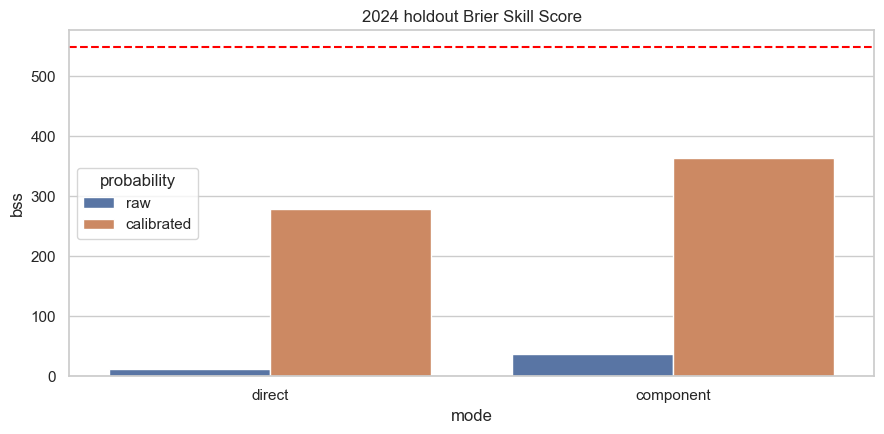

In [8]:
def fit_brier_calibrator(probability, target):
    probability = np.clip(np.asarray(probability), 1e-5, 1 - 1e-5)
    logit = np.log(probability / (1 - probability))
    x = torch.tensor(logit, dtype=torch.float64)
    y = torch.tensor(target, dtype=torch.float64)
    a = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
    b = torch.tensor(0.0, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.LBFGS([a, b], lr=0.2, max_iter=80, line_search_fn="strong_wolfe")
    def closure():
        optimizer.zero_grad()
        p = torch.sigmoid(a * x + b)
        loss = torch.mean((p - y) ** 2)
        loss.backward()
        return loss
    optimizer.step(closure)
    return float(a.detach()), float(b.detach())

def apply_calibrator(probability, calibrator):
    p = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    logit = np.log(p / (1 - p))
    a, b = calibrator
    return 1 / (1 + np.exp(-(a * logit + b)))


comparison_rows = []
calibrators = {}
holdout_predictions = {}
for mode, candidate_model in candidates.items():
    select_p, select_y = predict_model(candidate_model, select_loader)
    calibrator = fit_brier_calibrator(select_p, select_y)
    calibrators[mode] = calibrator
    select_cal = apply_calibrator(select_p, calibrator)

    holdout_p, holdout_y = predict_model(candidate_model, holdout_loader)
    holdout_cal = apply_calibrator(holdout_p, calibrator)
    holdout_predictions[mode] = holdout_cal

    for split_name, y, raw, calibrated in [
        ("2023_select", select_y, select_p, select_cal),
        ("2024_holdout", holdout_y, holdout_p, holdout_cal),
    ]:
        for calibration_name, p in [("raw", raw), ("calibrated", calibrated)]:
            comparison_rows.append({"mode": mode, "split": split_name, "probability": calibration_name,
                                    **brier_report(y, p), "cal_a": calibrator[0], "cal_b": calibrator[1]})

comparison = pd.DataFrame(comparison_rows)
selection_table = comparison.query("split == '2023_select' and probability == 'calibrated'")
selected_mode = selection_table.sort_values(["brier", "mode"]).iloc[0]["mode"]

comparison.to_csv(OUTPUT_DIR / "brier_model_comparison.csv", index=False)
display(comparison.sort_values(["split", "brier"]))
print("selected mode from 2023 only:", selected_mode, "calibrator:", calibrators[selected_mode])

plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison.query("split == '2024_holdout'"), x="mode", y="bss", hue="probability")
plt.axhline(549.51, color="red", linestyle="--", label="completion threshold 549.51")
plt.title("2024 holdout Brier Skill Score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "brier_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


## 8. 선택 모델 전체 재학습과 제출용 artifact

모델 구조·손실·보정 방식 선택이 끝났으므로 2019~2024 전체 학습 데이터로 선택 모델을 다시 학습합니다. 빠른 모드에서는 최대 60만 행을 사용합니다.

제출 artifact에는 다음만 저장합니다.

- PyTorch 가중치
- NumPy 전처리 통계
- 고정 투수 ID 사전 및 cohort 사전
- 공식 train+Trackman으로 미리 만든 2025 cutoff Trackman lookup
- 2023에서 고정한 2-파라미터 확률 보정값

평가 시 test 전체를 집계하거나 crosswalk를 다시 만들지 않습니다.

In [9]:
final_pool = model_df.index[eligible]
final_idx = sample_indices(final_pool, 600_000 if QUICK_RUN else None, SEED + 10)
final_hist_prep = fit_preprocessor(model_df.loc[final_idx], HISTORY_FEATURES)
final_tm_prep = fit_preprocessor(model_df.loc[final_idx], TRACKMAN_FEATURES)
final_pitchers = np.sort(model_df.pitcher_id.unique())
final_pitcher_to_index = {int(pid): i + 1 for i, pid in enumerate(final_pitchers)}
final_arrays = make_arrays(final_idx, final_hist_prep, final_tm_prep, final_pitcher_to_index)
final_loader = make_loader(final_arrays, True)

torch.manual_seed(SEED + 999)
final_model = PitcherBrierNet(len(HISTORY_FEATURES), len(TRACKMAN_FEATURES), len(final_pitcher_to_index),
                              len(COHORTS), mode=selected_mode).to(DEVICE)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=1e-3, weight_decay=1e-4)
for epoch in range(1, EPOCHS + 1):
    final_model.train()
    totals = np.zeros(2)
    seen = 0
    for history_x, trackman_x, pitcher_idx, cohort_idx, asof_n, y in final_loader:
        history_x, trackman_x = history_x.to(DEVICE), trackman_x.to(DEVICE)
        pitcher_idx, cohort_idx, asof_n, y = pitcher_idx.to(DEVICE), cohort_idx.to(DEVICE), asof_n.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        direct_logit, component_logits, _ = final_model(history_x, trackman_x, pitcher_idx, cohort_idx, asof_n)
        loss, parts = model_loss(final_model, direct_logit, component_logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), 5.0)
        optimizer.step()
        n = len(y)
        totals += np.array([loss.item(), parts["brier"].item()]) * n
        seen += n
    print(f"final epoch {epoch:02d} | loss={totals[0]/seen:.6f} | brier={totals[1]/seen:.6f}")

# cutoff=2025: 2019~2024만 포함한 고정 Trackman 요약
tm_2025 = build_lagged_trackman(tm, cutoffs=[2025])
track_lookup_table = crosswalk[["pitcher_id", "pitcher_trackman_id"]].merge(
    tm_2025, on="pitcher_trackman_id", how="left"
)
for col in TRACKMAN_COUNT_RAW:
    track_lookup_table[col] = track_lookup_table[col].fillna(0)
track_lookup_table["tm_available"] = track_lookup_table.tm_prior_n.gt(0).astype("float32")

lookup_columns = [c for c in TRACKMAN_BASE_FEATURES if c in track_lookup_table.columns]
track_lookup = {}
for row in track_lookup_table[["pitcher_id"] + lookup_columns].itertuples(index=False):
    values = {}
    for name, value in zip(lookup_columns, row[1:]):
        values[name] = None if pd.isna(value) else float(value)
    track_lookup[int(row.pitcher_id)] = values

SUBMIT_DIR = PROJECT_ROOT / "experiment" / "pitcher_embedding" / "submit_v1"
MODEL_DIR = SUBMIT_DIR / "model"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "state_dict": {k: v.detach().cpu() for k, v in final_model.state_dict().items()},
    "mode": selected_mode,
    "embedding_dim": 32,
    "history_features": HISTORY_FEATURES,
    "trackman_features": TRACKMAN_FEATURES,
    "trackman_base_features": TRACKMAN_BASE_FEATURES,
    "trackman_count_raw": TRACKMAN_COUNT_RAW,
    "history_preprocessor": final_hist_prep,
    "trackman_preprocessor": final_tm_prep,
    "pitcher_to_index": final_pitcher_to_index,
    "cohort_to_index": cohort_to_index,
    "track_lookup": track_lookup,
    "calibrator": calibrators[selected_mode],
    "metadata": {
        "quick_run": QUICK_RUN, "epochs": EPOCHS, "seed": SEED,
        "train_rows": int(len(final_idx)), "crosswalk_pitchers": int(len(crosswalk)),
        "test_independent": True, "auxiliary_labels": selected_mode == "component",
    },
}
checkpoint_path = MODEL_DIR / "model.pt"
torch.save(checkpoint, checkpoint_path)

summary = {
    "selected_mode": selected_mode,
    "calibrator": list(calibrators[selected_mode]),
    "quick_run": QUICK_RUN,
    "final_train_rows": int(len(final_idx)),
    "crosswalk_pitchers": int(len(track_lookup)),
    "checkpoint_mb": checkpoint_path.stat().st_size / 1024**2,
    "holdout": comparison.query("mode == @selected_mode and split == '2024_holdout' and probability == 'calibrated'").iloc[0].to_dict(),
}
with open(OUTPUT_DIR / "submission_artifact_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2, default=float)

print(json.dumps(summary, ensure_ascii=False, indent=2, default=float))
print("checkpoint:", checkpoint_path)


final epoch 01 | loss=0.399511 | brier=0.252312


final epoch 02 | loss=0.391085 | brier=0.246741


final epoch 03 | loss=0.390593 | brier=0.246498


{
  "selected_mode": "component",
  "calibrator": [
    0.7223076080689524,
    -0.06739726632238101
  ],
  "quick_run": true,
  "final_train_rows": 600000,
  "crosswalk_pitchers": 419,
  "checkpoint_mb": 0.2832469940185547,
  "holdout": {
    "mode": "component",
    "split": "2024_holdout",
    "probability": "calibrated",
    "brier": 0.24891909956932068,
    "bss": 363.2325805913439,
    "logloss": 0.6909826545528746,
    "auc": 0.5368951046612755,
    "pred_mean": 0.4957326054573059,
    "target_mean": 0.4868299961090088,
    "cal_a": 0.7223076080689524,
    "cal_b": -0.06739726632238101
  }
}
checkpoint: C:\Users\isj67\Desktop\LGAIMERS\experiment\pitcher_embedding\submit_v1\model\model.pt


## 9. 운영진 확인용 질문 문안

아래 문안은 자동 게시하지 않습니다.

> **[DACON 답변 요청] train.csv 누적 asof 피처를 이용한 보조 라벨 생성 가능 여부**  
> 안녕하세요. 동일 투수의 다음 학습 행에 제공된 `asof_pitcher_reverse_rate` 및 `asof_pitcher_middle_rate`의 누적 변화량을 이용하여 현재 학습 행의 reverse/middle 보조 라벨을 복원하고, 이를 학습용 정답으로만 사용하는 것이 허용되는지 문의드립니다. 모델 입력에는 현재 행에서 투구 직전까지 확인 가능한 정보만 사용하며, 테스트 데이터의 다른 행·순서·분포·누적 통계는 일절 사용하지 않습니다. 해당 방식이 허용되지 않는다면 `control_success`만 직접 학습하는 모델을 사용하겠습니다.

최종 제출 전에는 `QUICK_RUN=False` 전체 학습, 서버 기본 버전과 같은 환경의 샘플 실행, zip 내부 최상위 구조 확인이 필요합니다.